In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.api as sm
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import datetime
from joblib import Parallel, delayed

: 

## Load Processed Transcriptomic Data

Three input files are necessary for executing the notebook:
1. Raw Transcriptomic Expression Data (Raw in the sense that these are not LOESS curves): `raw_exp_data`
2. Transcriptomic Sample Info: `sample_info`
3. Transcriptomic Variable Info: `variable_info`

Data are available in the repository published in *Nonlinear dynamics of multi-omics profiles during human aging*: https://github.com/jaspershen-lab/ipop_aging/blob/main/1-code/1_transcriptomics/1_data_preparation_cross_sectional.R. Data files can be produced by cloning the repository and running the linked script.
1. Raw Transcriptomic Data: `object_cross_section@expression_data`
2. Transcriptomic Sample Info: `object_cross_section@sample_info`
3. Transcriptomic Variable Info: `object_cross_section@variable_info`

Data should be put in the folder named `non_linear_aging_data/` and should be stored as `.csv` files

In [ ]:
# Folder with data = "non_linear_aging_data/"
raw_transcriptomic_data = "" # Name of trancsriptomic data file
sample_info = "" # Name of sample_info file
transcript_variable_info = "" # Name of variable_info file

raw_exp_data = pd.read_csv(f"nonlinear_aging_data/{raw_transcriptomic_data}.csv")
sample_info = pd.read_csv(f"nonlinear_aging_data/{sample_info}.csv")
variable_info = pd.read_csv(f"nonlinear_aging_data/{transcript_variable_info}.csv")

In [4]:
exp_data = raw_exp_data.T
exp_data.reset_index(inplace=True)
exp_data.columns = ["Observation_ID"] + list(exp_data.iloc[0][1:])
exp_data = exp_data.iloc[1:]
exp_data = exp_data.merge(sample_info[["sample_id", "adjusted_age"]], left_on="Observation_ID", right_on = "sample_id",  how="left")
exp_data = exp_data.drop('sample_id', axis=1)
molecules = exp_data.columns[1:-1] 
exp_data["adjusted_age"] = exp_data["adjusted_age"].astype(float) # for some reason this is a string, convert to float

# Formatting for LOESS fitting
raw_exp_data.rename(columns={raw_exp_data.columns[0]: "Gene"}, inplace=True)
raw_exp_data.set_index("Gene", inplace=True)


### Age Distribution

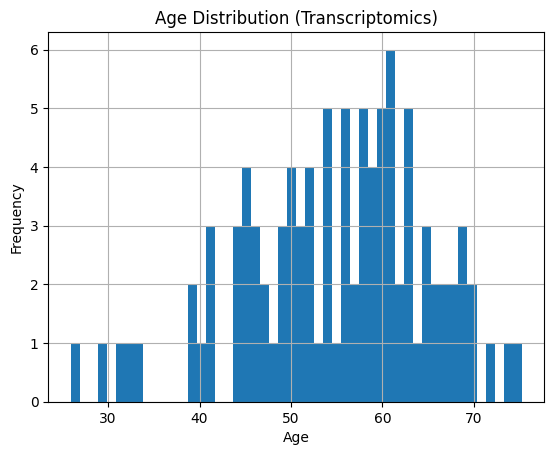

In [5]:
ax = exp_data["adjusted_age"].hist(bins=50)

ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
ax.set_title("Age Distribution (Transcriptomics)")

plt.show()

## DE-SWAN

### Run DE-SWAN without LOESS first

In [6]:
# Implementation of DE-SWAN as described in https://www.nature.com/articles/s41591-019-0673-2 but adapted to use a Wilcoxon test
def run_de_SWAN(molecules, window, age_col, exp_data, min_age=40, max_age=65, adj = True):

    mol_df = pd.DataFrame()
    mol_df["Molecule"] = molecules

    for midpt in range(min_age, max_age):  

        age = exp_data[age_col]

        # separate into young and old groups based on window around midpt
        young_df = exp_data[(age >= midpt - window) & (age < midpt)]
        old_df   = exp_data[(age >= midpt) & (age < midpt + window)]

        pvals = []
        for mol in molecules:

            # get molecule columns for young and old
            young_vals = list(young_df[mol].dropna())
            old_vals = list(old_df[mol].dropna())
            
            # run Mann-Whitney U test (Wilcoxen)
            _, p = mannwhitneyu(young_vals, old_vals, alternative="two-sided") # https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test
            pvals.append(p)
        
        if (adj):
            mol_df[str(midpt) + "_p_value"] = multipletests(pvals,  method='fdr_bh')[1]  
        else:
            mol_df[str(midpt) + "_p_value"] = pvals # UNADJ. BE CAREFUL; mostly for testing purposes
    
    return mol_df

def plot_peaks(sig_mol_df):

    # count number of significant molecules at each midpt (p_adj < 0.05)
    sig_cts = []
    for pvc in sig_mol_df.columns[1:]:
        sig_ct = int((sig_mol_df[pvc] < 0.05).sum())
        sig_cts.append(sig_ct)

    midpts = [int(col.split("_")[0]) for col in sig_mol_df.columns[1:]]

    plt.plot(midpts, sig_cts) # The plot() function draws a line by connecting data points.

    plt.xlabel('Age (years)')
    plt.ylabel('No. of significant genes (p < 0.05)')

    plt.show()

    return (midpts, sig_cts)

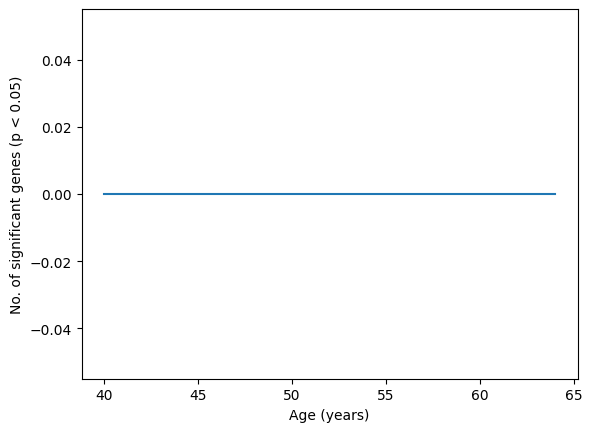

([40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [7]:
# Call DE-SWAN
window = 10 # midpt - window to midpt + window
mol_df = run_de_SWAN(molecules, window, "adjusted_age", exp_data,adj=True) # Run DE-SWAN to get the significant molecules across age midpoints
plot_peaks(mol_df) 

### Run DE-SWAN with LOESS first

In [8]:
# Use LOESS implementation in R to fit curves for each molecule across age
# Adapts LOESS code from https://github.com/jaspershen-lab/ipop_aging
def run_loess(variable_info, sample_info, raw_exp_data, sup_neg):
    
    if "sample_id" in sample_info.columns:
        raw_exp_data = raw_exp_data.loc[:, sample_info["sample_id"].tolist()]
    
    # source your R file
    ro.r['source']("loess.R")

    run_loess_r = ro.globalenv["run_loess"]

    with localconverter(ro.default_converter + pandas2ri.converter):
        r_variable_info = ro.conversion.py2rpy(variable_info)
        r_sample_info   = ro.conversion.py2rpy(sample_info)
        r_expression    = ro.conversion.py2rpy(raw_exp_data)

        r_out = run_loess_r(r_variable_info, r_sample_info, r_expression, sup_neg)

        loess_out = ro.conversion.rpy2py(r_out)

    return loess_out

In [9]:
# Takes ~40 minutes 
loess_out = run_loess(variable_info, sample_info, raw_exp_data, False)

/opt/miniconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "CL2". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
/opt/miniconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "collection_date_sspg". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99  100  101  102  103  104  105  106  107  108  109  110  111  112  113  114  115  116  117  118  119  120  121  122  123  124  125  126  127  128  129  130  131  132  133  134  135  136  137  138  139  140  141  142  143  144  145  146  147  148  149  150  151  152  153  154  155  156  157  158  159  160  161  162  163  164  165  166  167  168  169  170  171  172  173  174  175  176  177  178  179  180  181  182  183  184  185  186  187  188  189  190  191  192  193  194  195  196  197  198  199  200  201  202  203  204  205  206  207  208  209  210  211  212  213  214  215  216  217  218  219  220  221  222

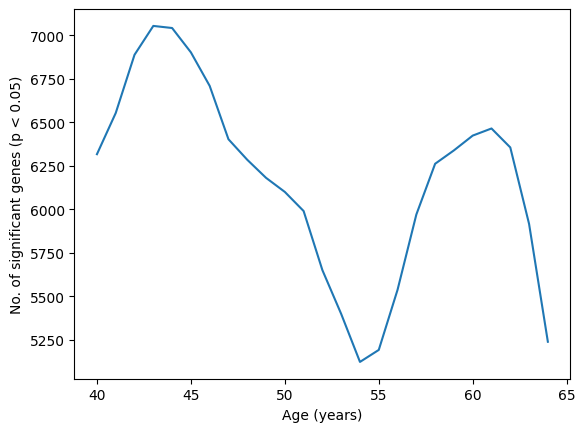

([40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64],
 [6317,
  6554,
  6889,
  7055,
  7043,
  6903,
  6710,
  6403,
  6285,
  6181,
  6100,
  5990,
  5650,
  5398,
  5122,
  5191,
  5537,
  5970,
  6262,
  6339,
  6424,
  6465,
  6356,
  5916,
  5238])

In [10]:
loess_df = loess_out.T.reset_index()
loess_df.rename(columns={"index": "Age"}, inplace=True)
loess_df["Age"] = loess_df["Age"].astype(float)
loess_mol_df = run_de_SWAN(list(loess_df.columns[1:]), window, "Age", loess_df)
plot_peaks(loess_mol_df)

## Permutations

These results can take a while to run so the code is commented by default. Previous results have been saved in the `permutation_rslts` folder and loaded in the cell below.

### Option 1: Use previously saved permutation results.

In [15]:
# Comment to run permutations - this will load saved results of permutations 
permutation_results = pd.read_csv("permutation_rslts/2026-02-23_transcriptomic_permutation_results.csv") # largest number of permutations run; n = 80
n_permutations = len(permutation_results)

### Option 2: Re-run permutation analysis (uncomment below).

In [16]:
## This will take a long time. Consider running on a cluster or reducing the number of permutations for testing purposes.
## Otherwise, load previously saved permutation results from "permutation_rslts/" folder

# n_permutations = 40
# ct_cols = ["permutation_i"] + list(map(str, range(40, 65)))

# def run_one_permutation(i, variable_info, sample_info, raw_exp_data, window):
#     # Make a permuted copy
#     sample_info_perm = sample_info.copy()
#     sample_info_perm["adjusted_age"] = np.random.permutation(
#         sample_info_perm["adjusted_age"].values
#     )

#     # Run LOESS
#     loess_out_permute = run_loess(variable_info, sample_info_perm, raw_exp_data, False)

#     # Clean output
#     loess_perm_df = loess_out_permute.T.reset_index()
#     loess_perm_df.rename(columns={"index": "Age"}, inplace=True)
#     loess_perm_df["Age"] = loess_perm_df["Age"].astype(float)

#     # Run DE-SWAN
#     perm_mol_df = run_de_SWAN(list(raw_exp_data.index), window, "Age", loess_perm_df)
#     _, sig_cts = plot_peaks(perm_mol_df)

#     return [i] + list(sig_cts)

# results = Parallel(n_jobs=-1, backend="loky")(
#     delayed(run_one_permutation)(
#         i, variable_info, sample_info, raw_exp_data, window
#     )
#     for i in range(n_permutations)
# )

# permutation_results = pd.DataFrame(results, columns=ct_cols)

# current_datetime = datetime.datetime.now()
# date_stamp = current_datetime.strftime("%Y-%m-%d_%H-%M")
# permutation_results.to_csv(f"permutation_rslts/{date_stamp}_transcriptomic_permutation_results.csv", index=False)



In [17]:
def plot_permutations(permutation_results, true_data, show_curves=True):
    midpts = [int(col) for col in permutation_results.columns[1:]]

    # rows=permutations, cols=ages
    Y = permutation_results.iloc[:, 1:].apply(pd.to_numeric, errors="coerce").to_numpy()

    if show_curves:
        for i in range(Y.shape[0]):
            plt.plot(midpts, Y[i, :], color="gray", alpha=0.2, linewidth=1)
    
    if true_data is not None:
        true_data_DE_SWAN = run_de_SWAN(list(true_data.columns[1:]), window, "Age", true_data)

        sig_cts = []
        for pvc in true_data_DE_SWAN.columns[1:]:
            sig_ct = int((true_data_DE_SWAN[pvc] < 0.05).sum())
            sig_cts.append(sig_ct)
        plt.plot(
            midpts,
            sig_cts,
            color="blue",
            linewidth=3,
            label=f"True Data"
        )

    plt.xlabel("Age (years)")
    plt.ylabel("No. of significant molecules (q < 0.05; FDR Adj.)")
    plt.title(f"{permutation_results.shape[0]} Permutations of LOESS+DE-SWAN")
    plt.legend()
    plt.tight_layout()
    plt.show()

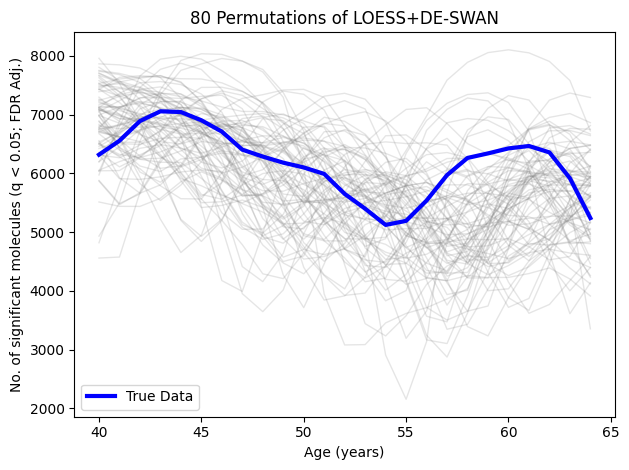

In [18]:
plot_permutations(permutation_results,loess_df)

#### Illustration of Differences for Permutation Tests - Molecule A1BG

In [17]:
# A1BG

# shuffle post-LOESS
loess_exp_shuff = loess_df.copy()
loess_exp_shuff["Age_shuffled"] = np.random.permutation(loess_exp_shuff["Age"].values)
loess_exp_shuff.drop(columns=["Age"], inplace=True)

# shuffle pre-LOESS
sample_info_perm= sample_info.copy()
sample_info_perm["adjusted_age"] = np.random.permutation(sample_info_perm["adjusted_age"].values)
# loess the data with the shuffled ages

# note: age column has to be named "adjusted_age" because that's what their R code usses
loess_out_permute = run_loess(variable_info, sample_info_perm, raw_exp_data) 

# clearn output and convert to dataframe
loess_perm_df = loess_out_permute.T.reset_index()
loess_perm_df.rename(columns={"index": "Age"}, inplace=True)
loess_perm_df["Age"] = loess_perm_df["Age"].astype(float)


/opt/miniconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "CL2". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
/opt/miniconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "collection_date_sspg". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99  100  101  102  103  104  105  106  107  108  109  110  111  112  113  114  115  116  117  118  119  120  121  122  123  124  125  126  127  128  129  130  131  132  133  134  135  136  137  138  139  140  141  142  143  144  145  146  147  148  149  150  151  152  153  154  155  156  157  158  159  160  161  162  163  164  165  166  167  168  169  170  171  172  173  174  175  176  177  178  179  180  181  182  183  184  185  186  187  188  189  190  191  192  193  194  195  196  197  198  199  200  201  202  203  204  205  206  207  208  209  210  211  212  213  214  215  216  217  218  219  220  221  222

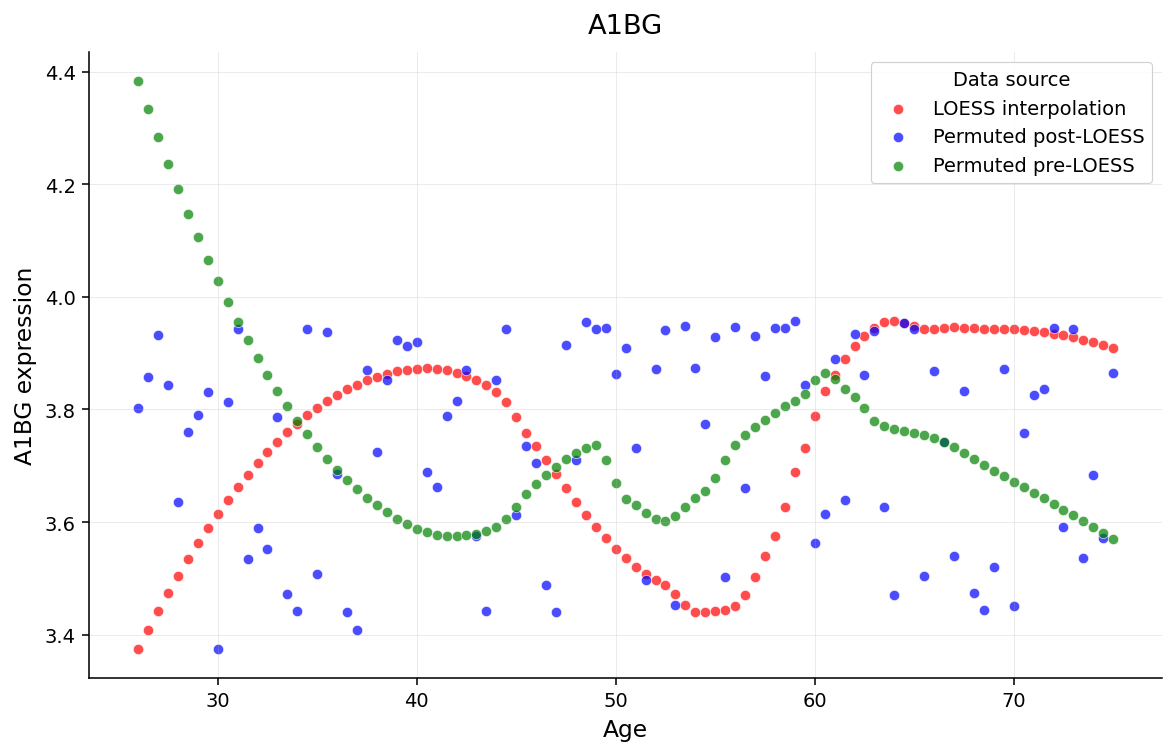

In [ ]:
# plot 
fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=140)

common = dict(s=28, alpha=0.7, linewidth=0.4, edgecolors="white")

ax.scatter(loess_df["Age"], loess_df["A1BG"],
           label="LOESS interpolation", color="red", **common)

ax.scatter(loess_exp_shuff["Age_shuffled"], loess_exp_shuff["A1BG"],
           label="Permuted post-LOESS", color="blue", **common)

ax.scatter(loess_perm_df["Age"], loess_perm_df["A1BG"],
           label="Permuted pre-LOESS", color="green", **common)

ax.set_title("A1BG", fontsize=14, pad=10)
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("A1BG expression", fontsize=12)

# Subtle grid + cleaner frame
ax.grid(True, which="major", linestyle="-", linewidth=0.5, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Single, clean legend
leg = ax.legend(title="Data source", loc="upper right", frameon=True)
leg.get_frame().set_alpha(0.9)
leg.get_frame().set_linewidth(0.6)

plt.tight_layout()
plt.show()